In [5]:
import sys
sys.path.append("../../src/")
from common_imports import *
from scipy.integrate import solve_ivp
from numpy import conj
from numpy import linalg as la
import kibble_zurek as kz
from time import time
from joblib import Parallel, delayed
import numpy as np
import time_evolved_z_correlators as zz
#Load Pauli Matrices
s3,s1,s2 = array([[1,0],[0,-1]],dtype=complex),array([[0, 1],[1,0]],dtype=complex), array([[0,-1j],[1j,0]],dtype=complex)


In [31]:

def g(t,tau,alpha=1):
    """
    Time Dependent g(t) with a potential nonlinearity in quench speed controlled by alpha.
    """
    return 1 - np.sign(t)*abs(t/tau)**(alpha)
#TFIM functions
def a(q,g):
    return g+ cos(q)
def b(q,g):
    return sin(q)
def w(q,g):
    return sqrt(g*g+2*g*cos(q)+1)
def BdG(q,g):
    return -2*(a(q,g)*s3+b(q,g)*s2)
#Time Evolution
def BdG_Evolution(t,U,tau,q,alpha=1):
    return -1j*BdG(q,g(t,tau,alpha))@U
def BdG_stationary_evolve(t,U,q,g):
    return -1j*BdG(q,g)@U
       

def evolve_mode(q, t0, tau, t_eval,alpha=1):
    V0 = la.eigh(BdG(q, g(t0, tau,alpha)))[1][:, 1]
    sol = solve_ivp(
        BdG_Evolution,
        [t0, tau],
        V0,
        args=(tau, q,alpha),
        t_eval=t_eval,
        method="DOP853",
        rtol=1e-10,
        atol=1e-12,
        max_step=0.05,
    )
    V1 = array([sol.y[0][-1],sol.y[1][-1]],dtype=complex)
    t_eval2= np.linspace(t_eval[-1],t_eval[-1]+tau,3000)
    sol2= solve_ivp(
        BdG_stationary_evolve,
        [t_eval2[0],t_eval2[-1]],
        V1,
        args =(q,g(t_eval[-1],tau,alpha)),
        t_eval=t_eval2,
        method="DOP853",
        rtol=1e-10,
        atol=1e-12,
        max_step=0.05,
    )

    u = np.concatenate( (sol.y[0] , sol2.y[0]) )
    v = np.concatenate( (sol.y[1] , sol2.y[1]) )
    print(len(u))
    return u,v


def landau_states(tau, L,alpha=1,ts=0):
    if ts==0:
        t0 = -tau
        tf = tau
    else:
        t0,tf = ts 
    n = np.arange(0, L // 2)
    k = (2 * n + 1) * pi / L
    t_eval = np.linspace(t0, tf, 3000)
    t_plot = np.concatenate( (t_eval, np.linspace(t_eval[-1],t_eval[-1]+tau,3000)))
    results = Parallel(n_jobs=-1, prefer="processes")(
        delayed(evolve_mode)(q, t0, tau, t_eval,alpha) for q in k
    )

    us, vs = map(np.array, zip(*results))
    states = [[us[:, i], vs[:, i], k] for i in range(len(t_plot))]
    return states, t_plot


In [42]:
states,t = landau_states(1,25)

6000
6000
6000
6000
6000
6000
6000
6000
6000
6000
6000
6000


In [56]:
x = [zz.P_n(5,s) for s in states]
x=array(x)

/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/0_quench_then_hold/../../src/time_evolved_z_correlators.py:49: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = kz.D(-Nd,state)


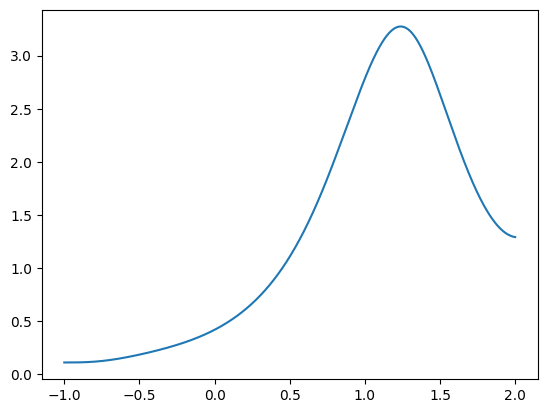

In [57]:
plot(t,-log(x))

In [15]:
evolve_mode(pi/4,-100,10,[1,2])

(array([ 0.17724923-0.10444602j, -0.14966416+0.15788407j,
        -0.14966416+0.15788407j, ...,  0.19126995+0.10170258j,
         0.19236573+0.09953739j,  0.1934378 +0.09735993j], shape=(3002,)),
 array([-0.48997841-0.84710973j,  0.7022828 +0.67784373j,
         0.7022828 +0.67784373j, ...,  0.45164294-0.86550046j,
         0.44201444-0.87046595j,  0.43233146-0.87532415j], shape=(3002,)))